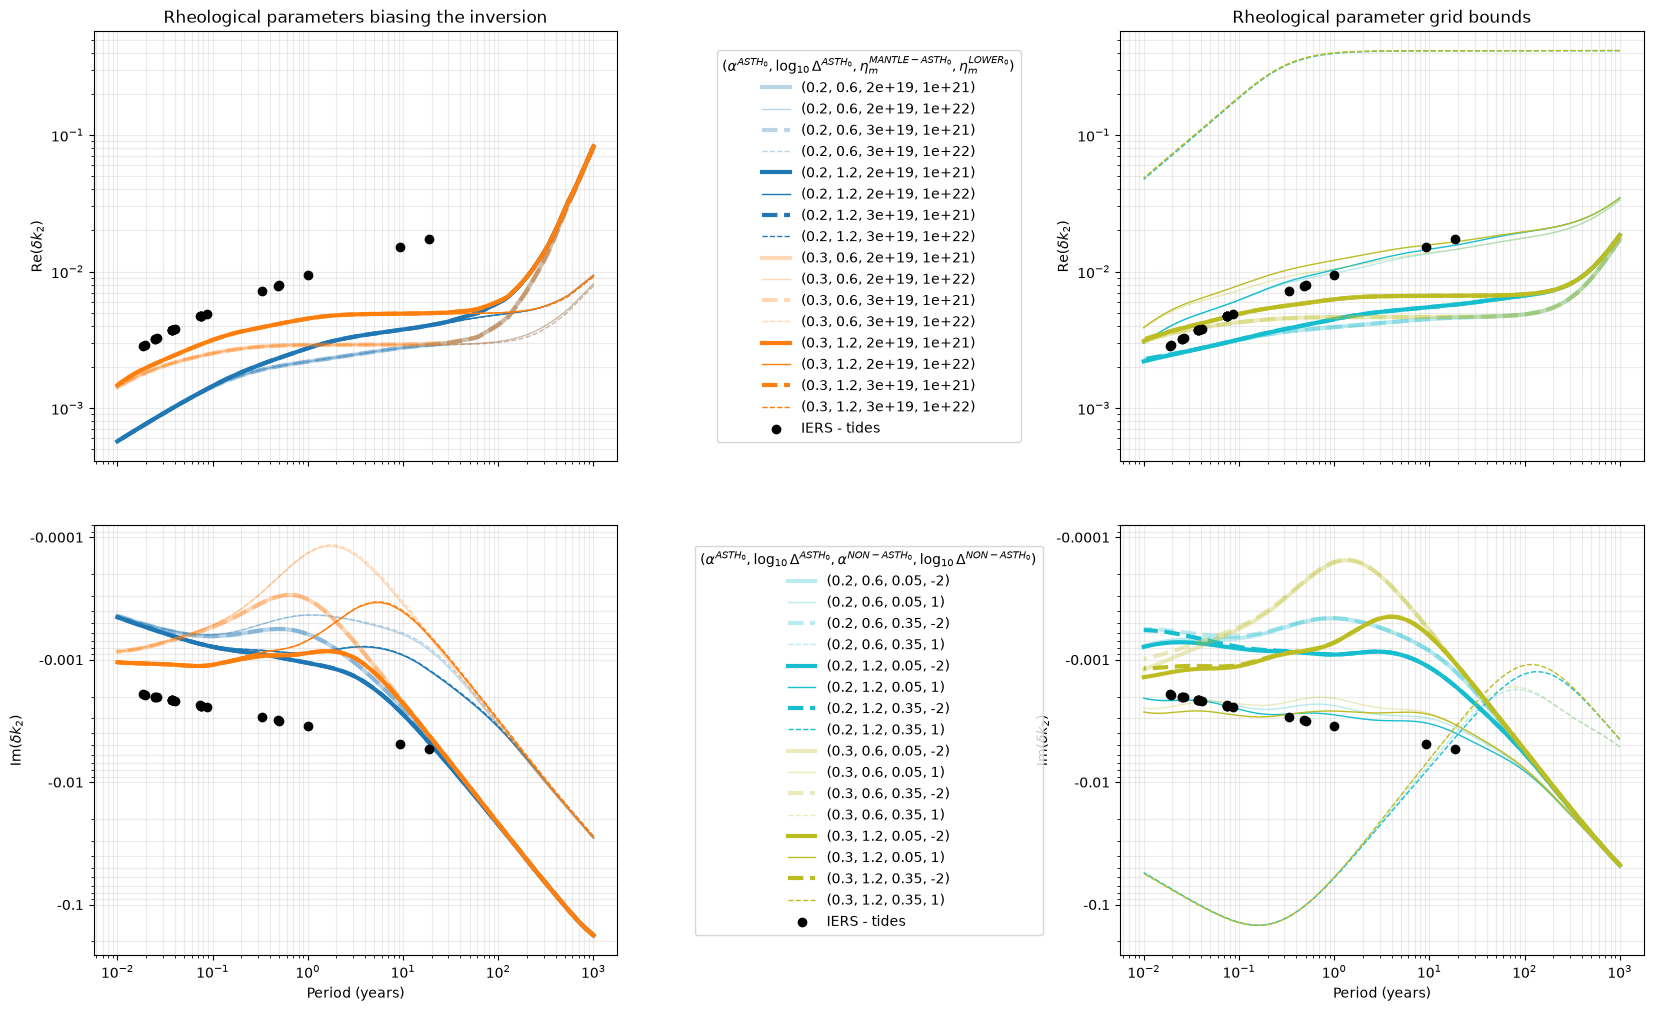

In [9]:
from alna import load_love_numbers_for_gins
from base_models import lagrange_order4
from numpy import linspace, exp, ndindex, ndarray, log
from matplotlib.pyplot import subplots, show
from numpy import array
from gins_partials.tide_correction_model import REFERENCE_K2, IERS_LONG_PERIOD_ZONAL_TIDES
from gins_partials.tide_correction_model import tide_angular_frequencies_to_cycle_per_yr

k2_reference = array(
    [
        REFERENCE_K2 + delta_k2_r + 1j * k2_i
        for _, _, delta_k2_r, k2_i in IERS_LONG_PERIOD_ZONAL_TIDES
    ],
    dtype=complex,
)
N_FREQ_PLOT = 1000

fig = subplots(figsize=(20, 12))[0]
fig.clear()
gs = fig.add_gridspec(
    2,
    3,
    width_ratios=(1, 0.4, 1),
    wspace=0.35,
    hspace=0.15,
)
ax_real_left = fig.add_subplot(gs[0, 0])
ax_imag_left = fig.add_subplot(gs[1, 0], sharex=ax_real_left)
ax_real_right = fig.add_subplot(gs[0, 2], sharex=ax_real_left, sharey=ax_real_left)
ax_imag_right = fig.add_subplot(gs[1, 2], sharex=ax_real_left, sharey=ax_imag_left)
legend_axes = [
    fig.add_subplot(gs[0, 1]),
    fig.add_subplot(gs[1, 1]),
]

for ax in legend_axes:

    ax.set_axis_off()

groups = [
    ("varying_biasing", ax_real_left, ax_imag_left),
    ("varying_mantle", ax_real_right, ax_imag_right),
]
TITLE_MAP = {
    "varying_biasing": "Rheological parameters biasing the inversion",
    "varying_mantle": "Rheological parameter grid bounds",
}
tide_periods = 1 / tide_angular_frequencies_to_cycle_per_yr()

for group, (directory, ax_real, ax_imag) in enumerate(groups):

    tabs, log_frequencies, elastic_love_numbers, anelastic_love_numbers, _ = (
        load_love_numbers_for_gins(directory=directory)
    )
    perturbations: ndarray = anelastic_love_numbers[..., 0, :] - elastic_love_numbers[0]
    new_log_frequencies = linspace(log(0.001), log_frequencies[-1], N_FREQ_PLOT)
    years = exp(-new_log_frequencies)
    alphas = linspace(0.3, 1.0, perturbations.shape[1])
    widths = linspace(3, 1, perturbations.shape[3])

    for index in ndindex(perturbations.shape[:-1]):

        parameters = tuple(values[i].item() for values, i in zip(tabs.values(), index))
        color_index = index[0] % 10
        style = dict(
            color=f"C{color_index if group == 0 else 9 - color_index}",
            alpha=alphas[index[1]],
            linestyle=("-", "--", "-.", ":")[index[2] % 4],
            linewidth=widths[index[3]],
        )

        for ax, values in (
            (ax_real, perturbations[index].real),
            (ax_imag, -perturbations[index].imag),
        ):

            ax.plot(
                years,
                lagrange_order4(log_frequencies, values, new_log_frequencies),
                label=(
                    "(" + ", ".join(f"{p:.2g}" for p in parameters) + ")" if ax is ax_real else None
                ),
                **style,
            )

    ax_real.scatter(
        tide_periods,
        k2_reference.real - elastic_love_numbers[0],
        color="black",
        label="IERS - tides",
        zorder=3,
    )
    ax_imag.scatter(
        tide_periods,
        -k2_reference.imag,
        color="black",
        zorder=3,
    )
    handles, labels = ax_real.get_legend_handles_labels()
    legend_axes[group].legend(
        handles,
        labels,
        title=rf"$({', '.join((parameter_name.replace("ASTHENOSPHERE", "ASTH").replace("-MANTLE", "") for parameter_name in tabs.keys()))})$",
        loc="center",
        borderaxespad=0,
    )
    ax_real.set_title(TITLE_MAP[directory])
    ax_real.tick_params(labelbottom=False)
    ax_imag.set_xlabel("Period (years)")

    for ax in (ax_real, ax_imag):

        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.grid(True, which="both", alpha=0.25)

    ax_real.set_ylabel(r"$\operatorname{Re}(\delta k_2)$")
    ax_imag.set_ylabel(r"$\operatorname{Im}(\delta k_2)$")

ax_imag_left.invert_yaxis()
ax_imag_left.yaxis.set_major_formatter(lambda y, _: f"{-y:g}")
show()